In [2]:
import os
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS
from rdkit.Chem import rdDistGeom
from rdkit.Chem import rdChemReactions
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers

In [23]:
gen_set_3 = [
'O=C1CCC(N2Cc3cc(S(=O)(=O)F)ccc3C2=O)C(=O)N1',
'O=C1CCC(N2Cc3c(cccc3S(=O)(=O)F)C2=O)C(=O)N1',
'O=C1CCC(c2ccc(S(=O)(=O)F)cc2)C(=O)N1',
'Cc1ccc(OC2CCC(=O)NC2=O)cc1S(=O)(=O)F',
'C[C@@H]1CN(c2ccc(S(=O)(=O)F)cc2)C(=O)NC1=O',
'O=C1CCC(Oc2cccc(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(Oc2cccc(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(N2C(=O)c3cc(S(=O)(=O)F)cc4cccc2c34)C(=O)N1',
'O=C1CCC(N2C(=O)c3cc(OS(=O)(=O)F)cc4cccc2c34)C(=O)N1',
'O=C1CCC(Oc2ccc(S(=O)(=O)F)cn2)C(=O)N1',
'Cn1nc(N2CCC(=O)NC2=O)c2cccc(S(=O)(=O)F)c21',
'CN(c1cccc(S(=O)(=O)F)c1)C1CCC(=O)NC1=O',
'CN(c1cccc(OS(=O)(=O)F)c1)C1CCC(=O)NC1=O',
'Cc1ccc(OC2C[C@H](C)C(=O)NC2=O)cc1OS(=O)(=O)F',
'Cc1cc(OC2CCC(=O)NC2=O)cc(OS(=O)(=O)F)c1',
'COc1cc(OC2CCC(=O)NC2=O)cc(OS(=O)(=O)F)c1',
'COc1cc(OC2CCC(=O)NC2=O)cc(S(=O)(=O)F)c1',
'O=C1CCC(CNc2cccc(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCN(c2ccc(OS(=O)(=O)F)cc2)C(=O)N1',
'COc1ccc(OC2CCC(=O)NC2=O)cc1S(=O)(=O)F',
'Cc1cc(OC2CCC(=O)NC2=O)cc(S(=O)(=O)F)c1',
'COc1ccc(OC2CCC(=O)NC2=O)cc1OS(=O)(=O)F',
'O=C1CCC(Oc2ccc(OS(=O)(=O)F)cn2)C(=O)N1',
'O=C1CCC(n2c(=O)oc3c(S(=O)(=O)F)cccc32)C(=O)N1',
'Cn1nc(N2CCC(=O)NC2=O)c2cccc(OS(=O)(=O)F)c21',
'O=C1CCC(Nc2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1NC(=O)C2(Nc3ccc(S(=O)(=O)F)cc3)CC1C2',
'O=C1NC(=O)C2(c3ccc(S(=O)(=O)F)cc3)CC1C2',
'O=C1CCN(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCN(c2ccc(N3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(Oc2ccc(C3CCNCC3)c(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(CNc2cccc(OS(=O)(=O)F)c2)C(=O)N1',
]

33


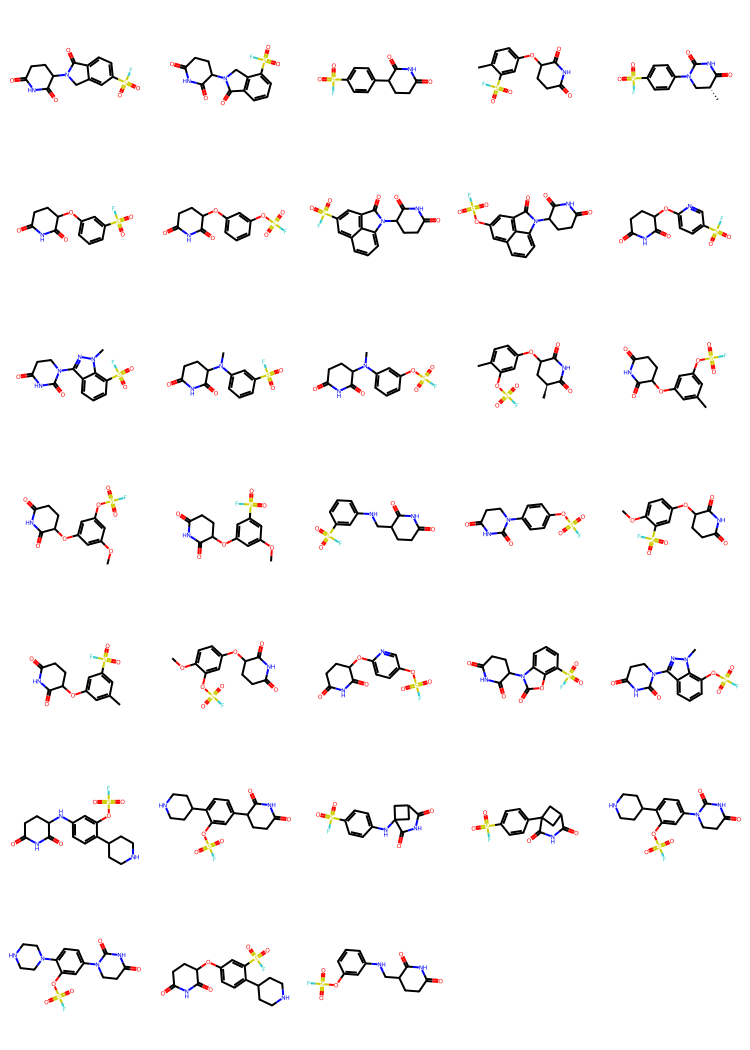

In [24]:
mol_list = []
for smi in gen_set_3:
    mol = Chem.MolFromSmiles(smi)
    Chem.SanitizeMol(mol)
    mol_list.append(mol)
print(len(mol_list))
Draw.MolsToGridImage(mol_list, molsPerRow=5, subImgSize=(150,150))

In [25]:
def All_Smiles_To_Covalent_Adducts_sdf(smiles_list, saved_conf_count=50, output_folder_path="cov_ligands"):
    ligand_sdf_path_list = []    
    try:
        os.makedirs(output_folder_path, exist_ok=True)
        all_isomers = []
        Histidine_fluorosulf_addition_smarts = (
            "[#9:0]-[#16:1](=[#8:2])(=[#8:3])-[*:4]>>[#6]-[#6]-[#6]1:[#7]:[#6]:[#7](-[#16:1](=[#8:2])(=[#8:3])-[*:4]):[#6]:1"
        )
        rxn_1 = rdChemReactions.ReactionFromSmarts(Histidine_fluorosulf_addition_smarts)
        rxn_2 = None
        rxn_3 = None
    
        for i in smiles_list:
            ligand_nonc = Chem.MolFromSmiles(i)
            Chem.SanitizeMol(ligand_nonc)
            ligand_nonc_isomers = list(EnumerateStereoisomers(ligand_nonc))
            for ii in ligand_nonc_isomers:
                try:
                    ligand_cov = rxn_1.RunReactants((ii,))[0][0]
                    Chem.SanitizeMol(ligand_cov)
                    Chem.AssignStereochemistry(
                        ligand_cov, force=True, flagPossibleStereoCenters=True
                    )
                    ligand_cov_isomers = list(EnumerateStereoisomers(ligand_cov))
                    for iii in ligand_cov_isomers:
                        all_isomers.append(iii)
                    if all_isomers:
                        print(f'molecule smiles {i} prepared for histidine fluorosulf addition successfully')
                    else:
                        raise ValueError(f'histidine fluorosulf addition failed for {i}')
                except:
                    try:
                        ligand_cov = rxn_2.RunReactants((ii,))[0][0]
                        Chem.SanitizeMol(ligand_cov)
                        Chem.AssignStereochemistry(
                            ligand_cov, force=True, flagPossibleStereoCenters=True
                        )
                        ligand_cov_isomers = list(EnumerateStereoisomers(ligand_cov))
                        for iii in ligand_cov_isomers:
                            all_isomers.append(iii)
                        if all_isomers:
                            print('None')
                        else:
                            raise ValueError('None')
    
                    except:
                        ligand_cov = rxn_3.RunReactants((ii,))[0][0]
                        Chem.SanitizeMol(ligand_cov)
                        Chem.AssignStereochemistry(
                            ligand_cov, force=True, flagPossibleStereoCenters=True
                        )
                        ligand_cov_isomers = list(EnumerateStereoisomers(ligand_cov))
                        for iii in ligand_cov_isomers:
                            all_isomers.append(iii)
                        if all_isomers:
                            print('None')
                        else:
                            raise ValueError('None')
                            
        print(f'Total number of isomers generated: {len(all_isomers)}')

        ps = rdDistGeom.ETKDGv3()
        ps.numThreads = 16
        
        for i, isomer in enumerate(all_isomers):
            energy_dict = {}  # conf_id as key; non_conc, energy as values
            Chem.SanitizeMol(isomer)
            isomer_H = Chem.AddHs(isomer)
            AllChem.EmbedMolecule(isomer_H, useRandomCoords=True, maxAttempts=1000)
            AllChem.EmbedMultipleConfs(isomer_H, 1000, ps)
            res = AllChem.MMFFOptimizeMoleculeConfs(isomer_H, maxIters=1000)
    
            for x, y in enumerate(res):
                energy_dict[x] = y
    
            sorted_energy_dict = {
                k: v for k, v in sorted(energy_dict.items(), key=lambda item: item[1][-1])
            }
            #keeping multiple minimised conformers
            pre_conf_id_list = []
            for a, b in sorted_energy_dict.items():
                if b[0] == 0:
                    pre_conf_id = a
                    pre_conf_id_list.append(a)
                    if len(pre_conf_id_list) >= saved_conf_count:
                        break
                    
            ligand_sdf_path = os.path.join(output_folder_path, f"ligand_{i}.sdf")
            ligand_sdf_path_list.append(ligand_sdf_path)
            writer = Chem.SDWriter(ligand_sdf_path)
            isomer_noH= Chem.RemoveAllHs(isomer_H)
            for pre_conf_id in pre_conf_id_list: 
                writer.write(isomer_noH, confId=pre_conf_id)
            writer.close()
        
    except Exception as e:
        print(f"Error occurred: {e}")
        print(f"Returning any existing SDF files in {output_folder_path}")
        if os.path.exists(output_folder_path):
            ligand_sdf_path_list = [os.path.join(output_folder_path, filename) for filename in os.listdir(output_folder_path) if filename.endswith('.sdf')]
        else:
            ligand_sdf_path_list = []

    return ligand_sdf_path_list

In [ ]:
All_Smiles_To_Covalent_Adducts_sdf(gen_set_3, saved_conf_count=50, output_folder_path="cov_ligands")

In [27]:
def split_cocrystal_structure(
    input_pdb_path, output_sdf_path, output_pdb_path
):
    from pymol import cmd
    cmd.delete("all")
    cmd.load(input_pdb_path)
    cmd.select("selection_ligand", "org.")
    cmd.extract("LG", "selection_ligand")
    cmd.h_add("LG")
    cmd.save(output_sdf_path, "LG", format="xyz")
    #cmd.select("selection_metal", "ino.")
    #cmd.remove("selection_metal")
    cmd.save(output_pdb_path, input_pdb_path.split("/")[-1].split(".")[-2])
    cmd.delete("all")
#
split_cocrystal_structure(
    input_pdb_path="4TZ4_binary.pdb",
    output_sdf_path="4TZ4_ligand.xyz",
    output_pdb_path="4TZ4_protein.pdb",
)
split_cocrystal_structure(
    input_pdb_path="5V3O_binary.pdb",
    output_sdf_path="5V3O_ligand.xyz",
    output_pdb_path="5V3O_protein.pdb",
)
split_cocrystal_structure(
    input_pdb_path="8OJH_binary.pdb",
    output_sdf_path="8OJH_ligand.xyz",
    output_pdb_path="8OJH_protein.pdb",
)

In [ ]:
!obabel -ixyz 4TZ4_ligand.xyz -osdf -O 4TZ4_ligand.sdf 
!obabel -ixyz 5V3O_ligand.xyz -osdf -O 5V3O_ligand.sdf
!obabel -ixyz 8OJH_ligand.xyz -osdf -O 8OJH_ligand.sdf

In [1]:
#run under conda pdbfixer env

from pdbfixer import PDBFixer
from openmm.app import PDBFile

def fix_protein_structure(input_pdb_path, output_pdb_path):

    fixer = PDBFixer(filename=input_pdb_path)

    #chains = list(fixer.topology.chains())
    #numChains = len(chains)

    # Keep only the chain crbn
    fixer.removeChains([0])

    # Remove heterogens including ion
    fixer.removeHeterogens(keepWater=False)
    # Perform the fixing steps
    fixer.findMissingResidues()
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(7.0)

    # Replace non-standard residues with standard ones
    fixer.findNonstandardResidues()
    fixer.nonstandardResidues = [(residue, 'ALA') for residue, replacement in fixer.nonstandardResidues]
    fixer.replaceNonstandardResidues()

    #Save the fixed structure
    with open(output_pdb_path, 'w') as f:
        PDBFile.writeFile(fixer.topology, fixer.positions, f)

fix_protein_structure(
    input_pdb_path="8OJH_protein.pdb",
    output_pdb_path="8OJH_protein_fixed.pdb",
)
fix_protein_structure(
    input_pdb_path="5V3O_protein.pdb",
    output_pdb_path="5V3O_protein_fixed.pdb",
)
fix_protein_structure(
    input_pdb_path="4TZ4_protein.pdb",
    output_pdb_path="4TZ4_protein_fixed.pdb",
)

In [ ]:
def get_mcs_aligned_rmsd(query_sdf_path, ref_sdf_path, aligned_sdf_path):

    confs = []
    # check the SMILES to verify aromaticity (lowercase atoms like 'c1ccccc1' indicate aromaticity)
    with Chem.SDMolSupplier(query_sdf_path, removeHs=True, sanitize=True) as suppl_query:
        for conf in suppl_query:
            if conf is None: continue
            #print(f"Query SMILES: {Chem.MolToSmiles(conf)}") 
            #display(Draw.MolToImage(conf))
            confs.append(conf)
            
    # Load reference molecule from XYZ file
    #ref_mol = Chem.MolFromXYZFile(ref_xyz_path)
    #display(Draw.MolToImage(ref_mol))
    #rdDetermineBonds.DetermineBondOrders(ref_mol, charge=0)    
    #print(f"Reference SMILES: {Chem.MolToSmiles(ref_mol)}")
    #display(Draw.MolToImage(ref_mol))

    with Chem.SDMolSupplier(ref_sdf_path, removeHs=True, sanitize=True) as suppl_ref:
        ref_mol = suppl_ref[0]
        #print(f"Reference SMILES: {Chem.MolToSmiles(ref_mol)}")
        #display(Draw.MolToImage(ref_mol))
        
    mcs = rdFMCS.FindMCS([confs[0], ref_mol], completeRingsOnly=True, ringMatchesRingOnly=False)
    patt = Chem.MolFromSmarts(mcs.smartsString)
    print(mcs.smartsString)

    #check patt contains imide
    imide_smarts = "[!#1]1(-[#6]-[#6]-[#6](-[#7]-[#6]-1=[#8])=[#8])-[!#1]"
    imide_mol = Chem.MolFromSmarts(imide_smarts)
    if not patt.HasSubstructMatch(imide_mol):
        print("Warning: auto MCS does not contain a cyclic imide group, use defined cyclic imide as MCS instead")
        patt = imide_mol
    display(Draw.MolToImage(patt))
    refMatch = ref_mol.GetSubstructMatch(patt)

    align_rms_min = None
    best_conf_id = None
    for i, conf in enumerate(confs):
        mv = conf.GetSubstructMatch(patt)
        #no_aligned_rms = AllChem.CalcRMS(conf, ref_mol, map=list(zip(mv, refMatch)))
        current_aligned_rms = AllChem.AlignMol(conf, ref_mol, atomMap=list(zip(mv, refMatch)))
        if (align_rms_min is None) or (current_aligned_rms < align_rms_min):
            align_rms_min = current_aligned_rms
            best_conf_id = i

    with Chem.SDWriter(aligned_sdf_path) as writer:
        writer.write(confs[best_conf_id])

    print(query_sdf_path)
    print(f"Best aligned conformation ID: {best_conf_id} with MCS RMSD: {align_rms_min}")
    print("-"*200)
    return best_conf_id, align_rms_min

for i in range(58):
    get_mcs_aligned_rmsd(
        query_sdf_path=f"cov_ligands/ligand_{i}.sdf",
        ref_sdf_path="4TZ4_ligand.sdf",
        aligned_sdf_path=f"cov_ligands/ligand_{i}_mcs_aligned_to_4TZ4.sdf",
    )